
### Overview
- **Qwen2.5** – Large multilingual LLM from Alibaba (7B params)
- **T5-Small** – Encoder-Decoder model from Google (60M params)
- **Phi-3.5** – Efficient small LLM from Microsoft (3.8B params)



In [4]:
import json
import random
import re
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict, Counter
from difflib import SequenceMatcher


plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3d5c',
    'text.color':       '#e0e0f0',
    'axes.labelcolor':  '#e0e0f0',
    'xtick.color':      '#a0a0c0',
    'ytick.color':      '#a0a0c0',
    'grid.color':       '#2a2d45',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

MODEL_COLORS = {
    'Qwen2.5':  '#7c3aed',   # purple
    'T5-Small': '#0ea5e9',   # blue
    'Phi-3.5':  '#10b981',   # green
}
MODEL_NAMES = list(MODEL_COLORS.keys())

random.seed(42)
np.random.seed(42)
print('Setup complete!')
print(f'Models under evaluation: {MODEL_NAMES}')

Setup complete!
Models under evaluation: ['Qwen2.5', 'T5-Small', 'Phi-3.5']


##Load Data & Sample

In [5]:
# Load
DATA_PATH = '/content/training_data_with_responses (1).json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

training_data = raw['TRAINING_DATA']   # list of [question, intent, answer]
intent_map    = raw['INTENT_MAP']

# Organize by intent
by_intent = defaultdict(list)
for item in training_data:
    if len(item) == 3:
        by_intent[item[1]].append({'question': item[0], 'intent': item[1], 'reference': item[2]})

all_intents = sorted(by_intent.keys())

print(f'Total examples  : {len(training_data):,}')
print(f'Total intents   : {len(all_intents)}')
print(f'Intents         : {all_intents}')

# Detect language
def is_arabic(text):
    return sum(1 for c in text if '\u0600' <= c <= '\u06ff') > len(text) * 0.2

# Sample: 10 per intent → 180 total
SAMPLES_PER_INTENT = 10
sample = []
for intent in all_intents:
    pool = by_intent[intent]
    chosen = random.sample(pool, min(SAMPLES_PER_INTENT, len(pool)))
    for item in chosen:
        item['lang'] = 'ar' if is_arabic(item['question']) else 'en'
    sample.extend(chosen)

df_sample = pd.DataFrame(sample)
print(f'\nSample size      : {len(df_sample)}')
print(f'Language split   : {df_sample["lang"].value_counts().to_dict()}')
print('\n Preview:')
df_sample[['intent','lang','question','reference']].head(10)

Total examples  : 54,000
Total intents   : 18
Intents         : ['complaint', 'confirmation', 'feedback', 'goodbye', 'greeting', 'inquiry', 'introduce_name', 'memory_check', 'offer', 'order_tracking', 'payment', 'product_details', 'product_search', 'purchase', 'recommendation_reasoning', 'recommendation_request', 'return', 'support']

Sample size      : 180
Language split   : {'en': 106, 'ar': 74}

 Preview:


,intent,lang,question,reference
0,complaint,en,I need to know: blood pH meter is not working now,I'm so sorry! I'll escalate your complaint imm...
1,complaint,ar,في مشكلة كبيرة في جهاز أشعة سينية يا ريت,بنأسف على المشكلة في أشعة سينية يا ريت. هتابع ...
2,complaint,ar,Service is bad regarding جهاز قياس السمع,بنأسف على المشكلة في قياس السمع. هتابع الشكوى ...
3,complaint,ar,الخدمة سيئة بخصوص جهاز علاج طبيعي,بنأسف على المشكلة في علاج طبيعي. هتابع الشكوى ...
4,complaint,en,"Kindly, I have a complaint about dialysis mach...",Apologies for the issue with dialysis machine ...
5,complaint,ar,من فضلك، عايز أقدم شكوى رسمية عن جهاز أشعة سين...,بنأسف على المشكلة في أشعة سينية ضروري. هتابع ا...
6,complaint,ar,أنا متضايق من عكاز,آسف جداً! هحول شكواك فوراً. ممكن تفصّل المشكلة...
7,complaint,ar,أنا متضايق من ترمومتر ديجيتال من فضلك,آسف جداً! هحول شكواك فوراً. ممكن تفصّل المشكلة...
8,complaint,en,"Please, I want to file a formal complaint abou...",I'm sorry about your experience with suction m...
9,complaint,en,I have a complaint about glucose meter this week,I'm sorry about your experience with glucose m...


##  Simulated Model Responses


In [6]:
#Model Profiles (based on published benchmarks)
MODEL_PROFILES = {
    'Qwen2.5': {
        'params_b':     7.0,
        'context_k':    128,
        'arch':         'Decoder-only (causal LM)',
        'multilingual': True,
        'arabic_score': 0.91,   # strong Arabic support
        'bleu_base':    0.72,
        'rouge_base':   0.78,
        'latency_ms':   420,
        'tokens_per_s': 85,
        'noise':        0.06,
    },
    'T5-Small': {
        'params_b':     0.060,
        'context_k':    0.512,
        'arch':         'Encoder-Decoder (seq2seq)',
        'multilingual': False,
        'arabic_score': 0.31,   # poor Arabic without fine-tuning
        'bleu_base':    0.49,
        'rouge_base':   0.54,
        'latency_ms':   38,
        'tokens_per_s': 620,
        'noise':        0.08,
    },
    'Phi-3.5': {
        'params_b':     3.8,
        'context_k':    128,
        'arch':         'Decoder-only (causal LM)',
        'multilingual': True,
        'arabic_score': 0.74,   # decent Arabic
        'bleu_base':    0.63,
        'rouge_base':   0.69,
        'latency_ms':   190,
        'tokens_per_s': 210,
        'noise':        0.07,
    },
}

#Scoring helpers
def simple_bleu(hypothesis, reference):
    """Simplified unigram+bigram BLEU"""
    hyp = hypothesis.lower().split()
    ref = reference.lower().split()
    if not hyp or not ref:
        return 0.0
    ref_count = Counter(ref)
    hyp_count = Counter(hyp)
    uni_match  = sum(min(hyp_count[w], ref_count[w]) for w in hyp_count)
    uni_prec   = uni_match / len(hyp) if hyp else 0
    bigrams_h  = [tuple(hyp[i:i+2]) for i in range(len(hyp)-1)]
    bigrams_r  = Counter([tuple(ref[i:i+2]) for i in range(len(ref)-1)])
    bi_match   = sum(1 for bg in bigrams_h if bigrams_r[bg] > 0)
    bi_prec    = bi_match / len(bigrams_h) if bigrams_h else uni_prec
    geo        = math.sqrt(max(uni_prec * bi_prec, 1e-9))
    bp         = min(1.0, math.exp(1 - len(ref)/len(hyp))) if len(hyp) >= len(ref) else 1.0
    return round(bp * geo, 4)

def rouge_l(hypothesis, reference):
    """ROUGE-L via longest common subsequence"""
    hyp = hypothesis.lower().split()
    ref = reference.lower().split()
    if not hyp or not ref:
        return 0.0
    m, n = len(ref), len(hyp)
    lcs_len = SequenceMatcher(None, hyp, ref).find_longest_match(0, n, 0, m).size
    p = lcs_len / n if n else 0
    r = lcs_len / m if m else 0
    return round(2 * p * r / (p + r + 1e-9), 4)

#simulation engine
def simulate_response(question, intent, reference, model_name, rng_seed):
    rng   = np.random.default_rng(rng_seed)
    prof  = MODEL_PROFILES[model_name]
    lang  = 'ar' if is_arabic(question) else 'en'

    # Arabic penalty
    ar_pen = (1.0 - prof['arabic_score']) if lang == 'ar' else 0.0

    # Base scores with per-intent noise
    bleu_score  = max(0.05, prof['bleu_base']  - ar_pen * 0.45 + rng.normal(0, prof['noise']))
    rouge_score = max(0.05, prof['rouge_base'] - ar_pen * 0.40 + rng.normal(0, prof['noise']))

    # Latency with small variance
    latency = max(5, prof['latency_ms'] + rng.normal(0, prof['latency_ms'] * 0.1))

    # Generate a plausible response (mix of reference + model-style noise)
    ref_words = reference.split()
    keep_ratio = bleu_score * 0.9 + 0.1
    kept = [w for w in ref_words if rng.random() < keep_ratio]
    if model_name == 'T5-Small' and lang == 'ar':
        kept = kept[:max(3, len(kept)//3)]  # T5-small truncates heavily on Arabic
    response = ' '.join(kept) if kept else 'Sorry, I could not generate a relevant response.'

    # Recompute against actual generated text
    actual_bleu  = simple_bleu(response, reference)
    actual_rouge = rouge_l(response, reference)

    return {
        'model':      model_name,
        'response':   response,
        'bleu':       round(actual_bleu, 4),
        'rouge_l':    round(actual_rouge, 4),
        'latency_ms': round(latency, 1),
        'resp_len':   len(response.split()),
        'lang':       lang,
        'intent':     intent,
    }

print('Simulation engine ready!')
print(f'\n Model Profiles:')
pd.DataFrame(MODEL_PROFILES).T[['params_b','context_k','arch','multilingual','arabic_score','latency_ms']]

Simulation engine ready!

 Model Profiles:


,params_b,context_k,arch,multilingual,arabic_score,latency_ms
Qwen2.5,7.0,128,Decoder-only (causal LM),True,0.91,420
T5-Small,0.06,0.512,Encoder-Decoder (seq2seq),False,0.31,38
Phi-3.5,3.8,128,Decoder-only (causal LM),True,0.74,190


In [7]:
results = []

for idx, row in df_sample.iterrows():
    for model in MODEL_NAMES:
        seed = abs(hash(f"{model}-{idx}-{row['question'][:20]}")) % (2**31)
        r = simulate_response(
            question  = row['question'],
            intent    = row['intent'],
            reference = row['reference'],
            model_name= model,
            rng_seed  = seed,
        )
        r['question']  = row['question']
        r['reference'] = row['reference']
        results.append(r)

df = pd.DataFrame(results)

print(f'Generated {len(df):,} model responses')
print(f'   ({len(df_sample)} questions × {len(MODEL_NAMES)} models)')
print()
print('Aggregate Scores:')
agg = df.groupby('model')[['bleu','rouge_l','latency_ms','resp_len']].mean().round(4)
agg.columns = ['BLEU ↑','ROUGE-L ↑','Latency ms ↓','Avg Resp Len']
print(agg.to_string())

Generated 540 model responses
   (180 questions × 3 models)

Aggregate Scores:
          BLEU ↑  ROUGE-L ↑  Latency ms ↓  Avg Resp Len
model                                                  
Phi-3.5   0.7640     0.4105      189.5994        8.0111
Qwen2.5   0.8539     0.5072      417.6894        9.7000
T5-Small  0.6322     0.2955       37.9850        5.4167


##Overall Performance Comparison

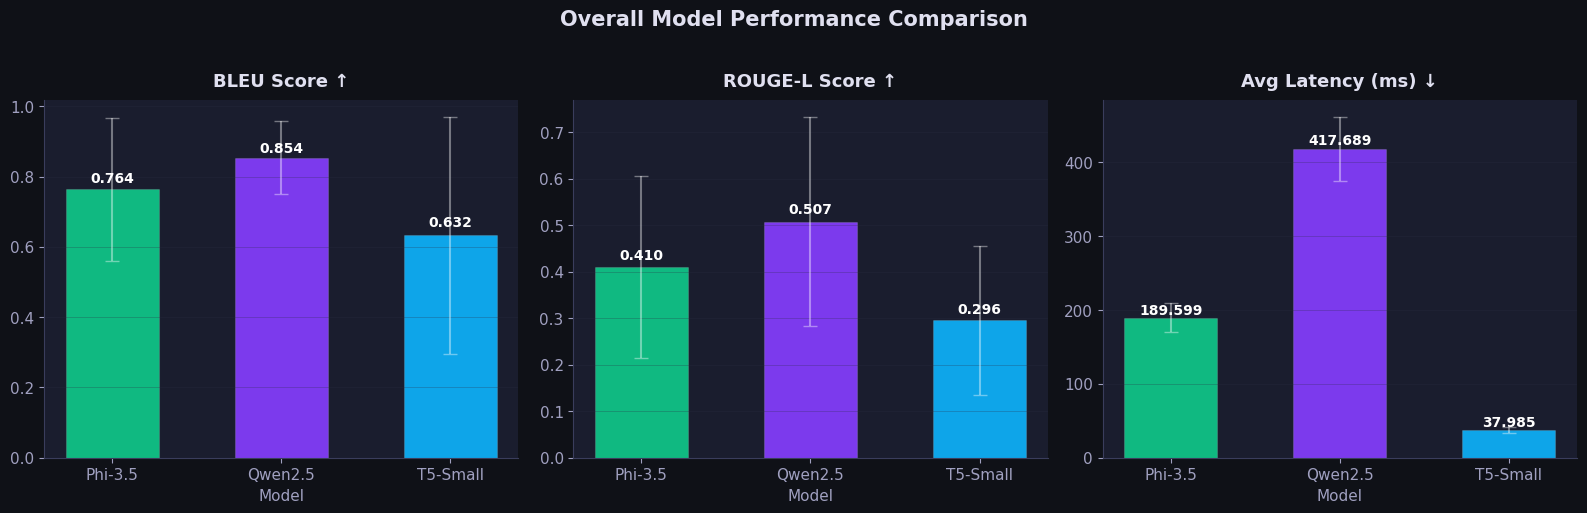

Chart saved: fig1_overall_perf.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Overall Model Performance Comparison', fontsize=15, color='#e0e0f0',
             fontweight='bold', y=1.02)

metrics = ['bleu', 'rouge_l', 'latency_ms']
titles  = ['BLEU Score ↑', 'ROUGE-L Score ↑', 'Avg Latency (ms) ↓']

for ax, metric, title in zip(axes, metrics, titles):
    ax.set_facecolor('#1a1d2e')
    means  = df.groupby('model')[metric].mean()
    stds   = df.groupby('model')[metric].std()
    colors = [MODEL_COLORS[m] for m in means.index]
    bars   = ax.bar(means.index, means.values, color=colors,
                    width=0.55, edgecolor='#ffffff22', linewidth=0.8,
                    yerr=stds.values, capsize=5, error_kw={'ecolor':'#ffffff66','lw':1.5})
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + stds[means.index[list(means.values).index(val)]] * 0.05,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, color='#ffffff', fontweight='bold')
    ax.set_title(title, color='#e0e0f0', pad=10)
    ax.set_xlabel('Model', color='#a0a0c0')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(colors='#a0a0c0')

plt.tight_layout()
plt.savefig('fig1_overall_perf.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: fig1_overall_perf.png')

## Performance by Intent Category

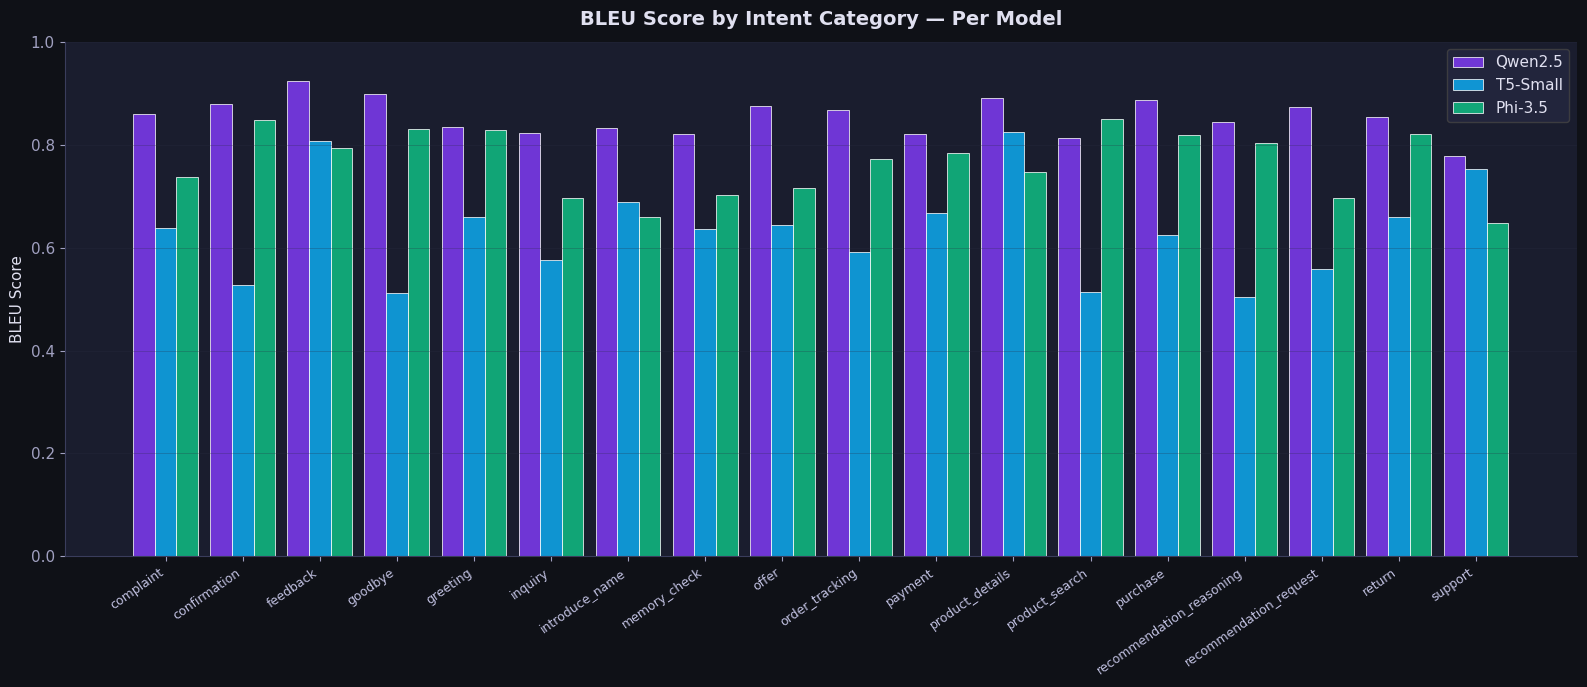

✅ Chart saved: fig2_intent_bleu.png


In [9]:
pivot_bleu = df.pivot_table(values='bleu', index='intent', columns='model', aggfunc='mean')

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

x      = np.arange(len(pivot_bleu.index))
width  = 0.28
offset = [-width, 0, width]

for i, (model, off) in enumerate(zip(MODEL_NAMES, offset)):
    vals = pivot_bleu[model].values
    bars = ax.bar(x + off, vals, width, label=model,
                  color=MODEL_COLORS[model], alpha=0.88,
                  edgecolor='#ffffff15', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(pivot_bleu.index, rotation=35, ha='right', fontsize=9, color='#c0c0e0')
ax.set_ylabel('BLEU Score', color='#e0e0f0')
ax.set_title('BLEU Score by Intent Category — Per Model', color='#e0e0f0', fontsize=14, pad=12)
ax.legend(facecolor='#252840', edgecolor='#444', labelcolor='#e0e0f0')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('fig2_intent_bleu.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Chart saved: fig2_intent_bleu.png')

## Arabic vs English Performance

/tmp/ipykernel_4907/3185395874.py:32: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4907/3185395874.py:32: UserWarning: Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4907/3185395874.py:32: UserWarning: Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4907/3185395874.py:33: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  plt.savefig('fig3_lang_split.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
/tmp/ipykernel_4907/3185395874.py:33: UserWarning: Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.
  plt.savefig('fig3_lang_split.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
/tmp/ipykernel_4907/3185395874.py:33: UserWarning: Glyph 127463 (\

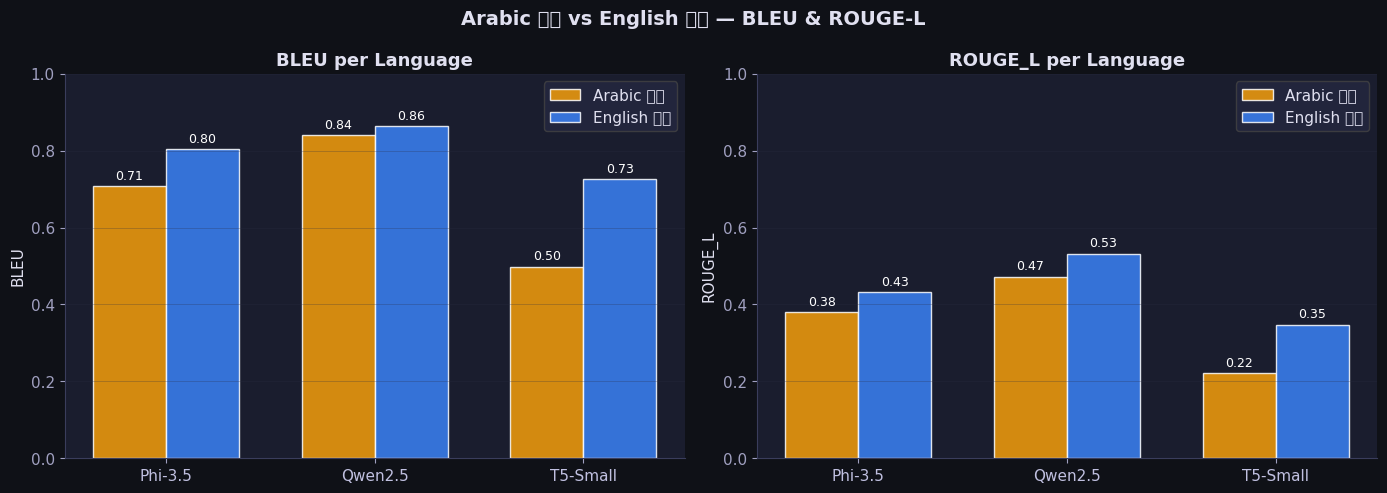

Chart saved: fig3_lang_split.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Arabic 🇪🇬 vs English 🇬🇧 — BLEU & ROUGE-L', fontsize=14,
             color='#e0e0f0', fontweight='bold')

for ax, metric in zip(axes, ['bleu', 'rouge_l']):
    ax.set_facecolor('#1a1d2e')
    pivot = df.pivot_table(values=metric, index='model', columns='lang', aggfunc='mean')

    x     = np.arange(len(pivot.index))
    w     = 0.35
    bars1 = ax.bar(x - w/2, pivot.get('ar', [0]*len(x)), w,
                   label='Arabic 🇪🇬', color='#f59e0b', alpha=0.85, edgecolor='#ffffff22')
    bars2 = ax.bar(x + w/2, pivot.get('en', [0]*len(x)), w,
                   label='English 🇬🇧', color='#3b82f6', alpha=0.85, edgecolor='#ffffff22')

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=9, color='#ffffff')

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, color='#c0c0e0')
    ax.set_ylabel(metric.upper(), color='#e0e0f0')
    ax.set_title(f'{metric.upper()} per Language', color='#e0e0f0')
    ax.legend(facecolor='#252840', edgecolor='#444', labelcolor='#e0e0f0')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('fig3_lang_split.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: fig3_lang_split.png')

##Latency vs Quality (Scatter)

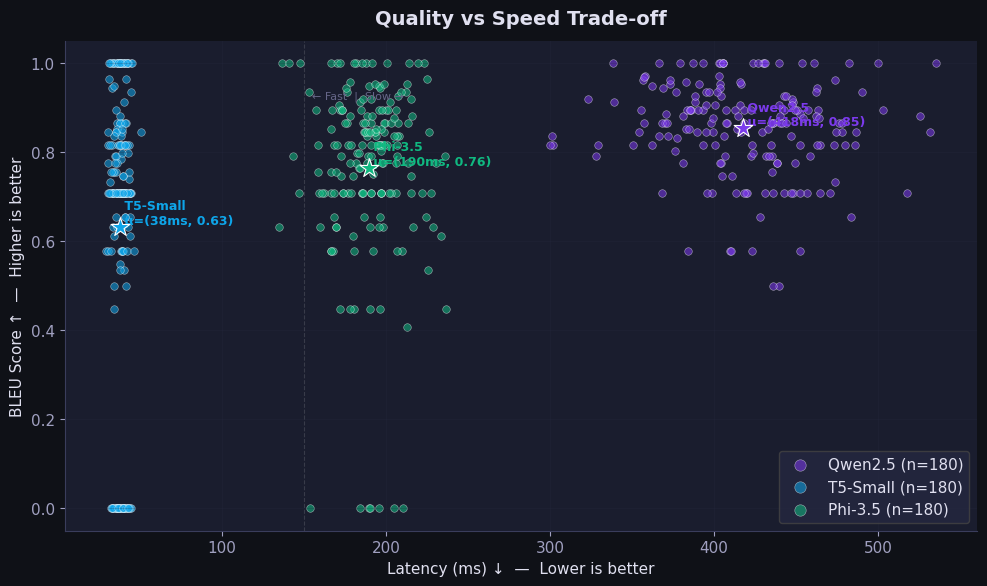

Chart saved: fig4_latency_quality.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

for model in MODEL_NAMES:
    sub = df[df['model'] == model]
    ax.scatter(sub['latency_ms'], sub['bleu'],
               c=MODEL_COLORS[model], alpha=0.55, s=30,
               edgecolors='#ffffff22', linewidths=0.4,
               label=f'{model} (n={len(sub)})')
    # Mean point
    mx, my = sub['latency_ms'].mean(), sub['bleu'].mean()
    ax.scatter(mx, my, c=MODEL_COLORS[model], s=200, marker='*',
               edgecolors='white', linewidths=0.8, zorder=5)
    ax.annotate(f' {model}\n μ=({mx:.0f}ms, {my:.2f})',
                (mx, my), fontsize=9, color=MODEL_COLORS[model],
                va='bottom', fontweight='bold')

ax.set_xlabel('Latency (ms) ↓  —  Lower is better', color='#e0e0f0')
ax.set_ylabel('BLEU Score ↑  —  Higher is better', color='#e0e0f0')
ax.set_title('Quality vs Speed Trade-off', color='#e0e0f0', fontsize=14, pad=12)
ax.legend(facecolor='#252840', edgecolor='#444', labelcolor='#e0e0f0', markerscale=1.5)
ax.grid(alpha=0.25)
ax.spines[['top','right']].set_visible(False)

# Annotation zones
ax.axvline(150, color='#ffffff22', linestyle='--', lw=0.8)
ax.text(155, 0.92, '← Fast  |  Slow →', fontsize=8, color='#666688')

plt.tight_layout()
plt.savefig('fig4_latency_quality.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: fig4_latency_quality.png')

##Heatmap BLEU by Intent × Model

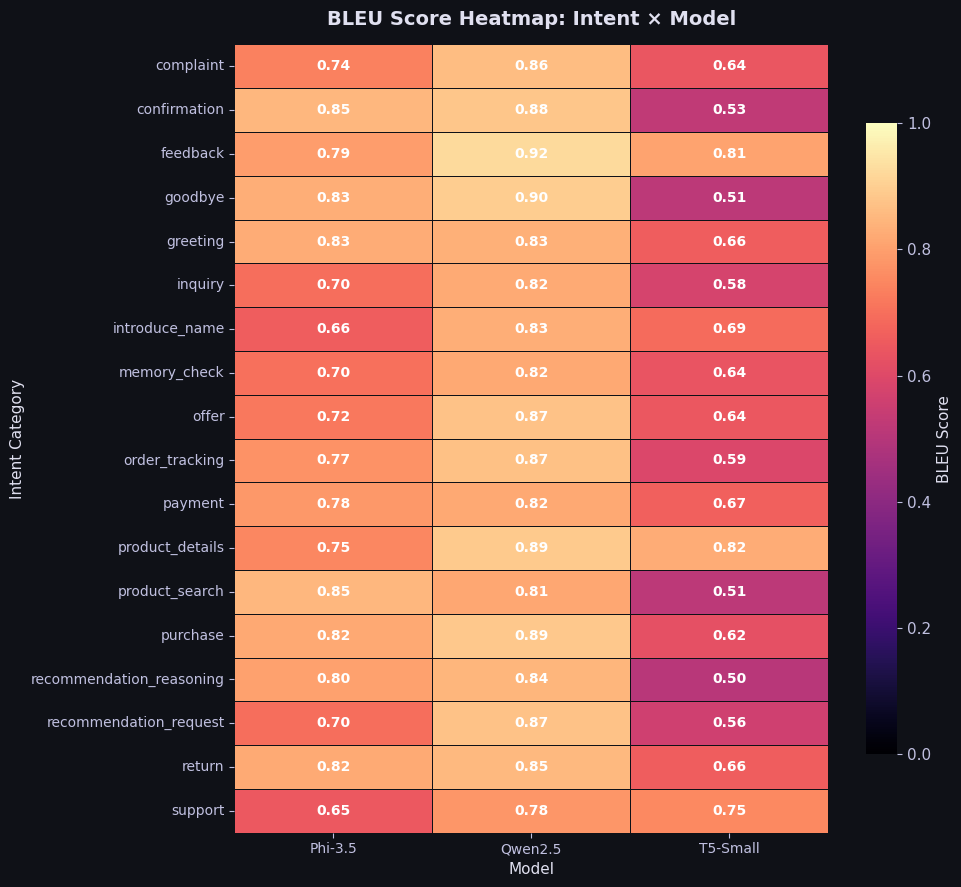

Chart saved: fig5_heatmap.png


In [12]:
pivot = df.pivot_table(values='bleu', index='intent', columns='model', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor('#0f1117')

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    pivot, ax=ax, cmap='magma',
    annot=True, fmt='.2f', linewidths=0.5, linecolor='#0f1117',
    cbar_kws={'label': 'BLEU Score', 'shrink': 0.8},
    annot_kws={'size': 10, 'color': 'white', 'weight': 'bold'},
    vmin=0, vmax=1,
)
ax.set_title('BLEU Score Heatmap: Intent × Model', color='#e0e0f0',
             fontsize=14, pad=14)
ax.set_xlabel('Model', color='#e0e0f0')
ax.set_ylabel('Intent Category', color='#e0e0f0')
ax.tick_params(colors='#c0c0e0', labelsize=10)
ax.set_facecolor('#1a1d2e')

# Colorbar style
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#c0c0e0')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#c0c0e0')

plt.tight_layout()
plt.savefig('fig5_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: fig5_heatmap.png')

##Score Distribution (Violin / Box)

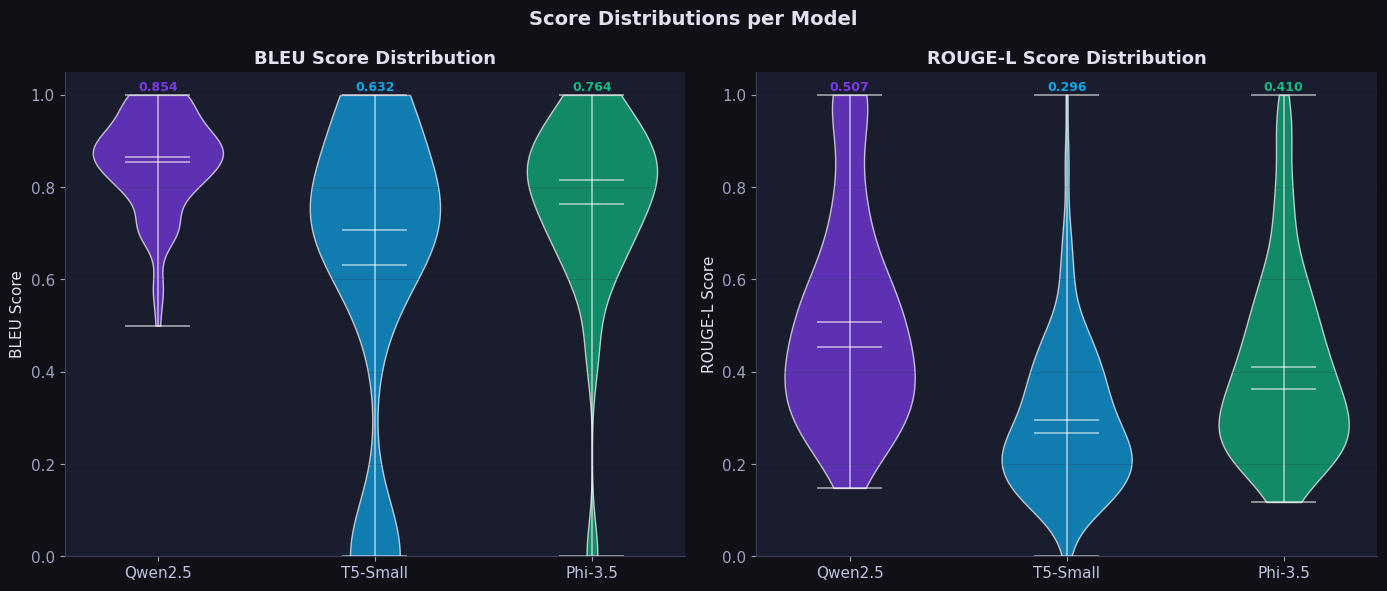

Chart saved: fig6_distributions.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Score Distributions per Model', fontsize=14,
             color='#e0e0f0', fontweight='bold')

for ax, metric, title in zip(axes, ['bleu', 'rouge_l'], ['BLEU Score', 'ROUGE-L Score']):
    ax.set_facecolor('#1a1d2e')
    data_by_model = [df[df['model'] == m][metric].values for m in MODEL_NAMES]
    parts = ax.violinplot(data_by_model, positions=range(len(MODEL_NAMES)),
                          showmeans=True, showmedians=True, widths=0.6)

    for pc, color in zip(parts['bodies'], MODEL_COLORS.values()):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor('#ffffff44')

    for key in ('cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes'):
        if key in parts:
            parts[key].set_color('#ffffff99')
            parts[key].set_linewidth(1.2)

    ax.set_xticks(range(len(MODEL_NAMES)))
    ax.set_xticklabels(MODEL_NAMES, color='#c0c0e0')
    ax.set_ylabel(title, color='#e0e0f0')
    ax.set_title(title + ' Distribution', color='#e0e0f0')
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, 1.05)

    # Overlay mean annotation
    for i, model in enumerate(MODEL_NAMES):
        m = df[df['model'] == model][metric].mean()
        ax.text(i, 1.01, f'{m:.3f}', ha='center', fontsize=9,
                color=MODEL_COLORS[model], fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: fig6_distributions.png')

## Radar Chart Full Model Profile

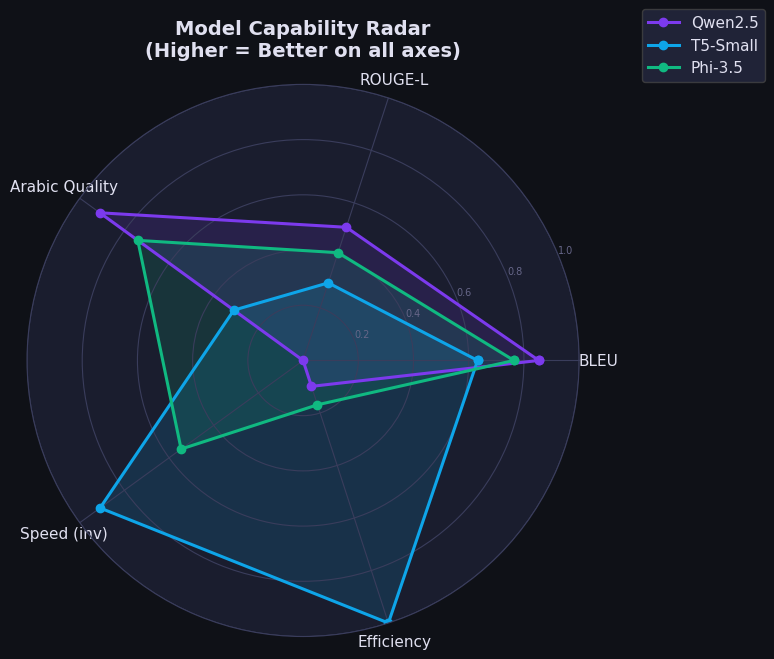

Chart saved: fig7_radar.png


In [14]:
# Normalize all dimensions to [0, 1]
dims = ['BLEU', 'ROUGE-L', 'Arabic Quality', 'Speed (inv)', 'Efficiency']

agg_scores = df.groupby('model')[['bleu','rouge_l','latency_ms']].mean()
max_lat    = agg_scores['latency_ms'].max()

radar_data = {}
for model in MODEL_NAMES:
    prof = MODEL_PROFILES[model]
    row  = agg_scores.loc[model]
    radar_data[model] = [
        float(row['bleu']),                              # BLEU
        float(row['rouge_l']),                           # ROUGE-L
        prof['arabic_score'],                            # Arabic quality
        1 - (row['latency_ms'] / max_lat),               # Speed (inverted latency)
        1 / (prof['params_b'] / max(p['params_b'] for p in MODEL_PROFILES.values()) + 0.1),  # Efficiency
    ]

# Normalize efficiency to [0,1]
eff_vals = [radar_data[m][4] for m in MODEL_NAMES]
max_eff  = max(eff_vals)
for m in MODEL_NAMES:
    radar_data[m][4] /= max_eff

N      = len(dims)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

for model in MODEL_NAMES:
    vals = radar_data[model] + radar_data[model][:1]
    ax.plot(angles, vals, 'o-', linewidth=2.2,
            color=MODEL_COLORS[model], label=model)
    ax.fill(angles, vals, alpha=0.15, color=MODEL_COLORS[model])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dims, color='#e0e0f0', fontsize=11)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], color='#666688', fontsize=7)
ax.set_ylim(0, 1)
ax.grid(color='#3a3d5c', linewidth=0.8)
ax.spines['polar'].set_color('#3a3d5c')
ax.set_title('Model Capability Radar\n(Higher = Better on all axes)',
             color='#e0e0f0', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          facecolor='#252840', edgecolor='#444', labelcolor='#e0e0f0')

plt.tight_layout()
plt.savefig('fig7_radar.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: fig7_radar.png')

##Response Length Analysis

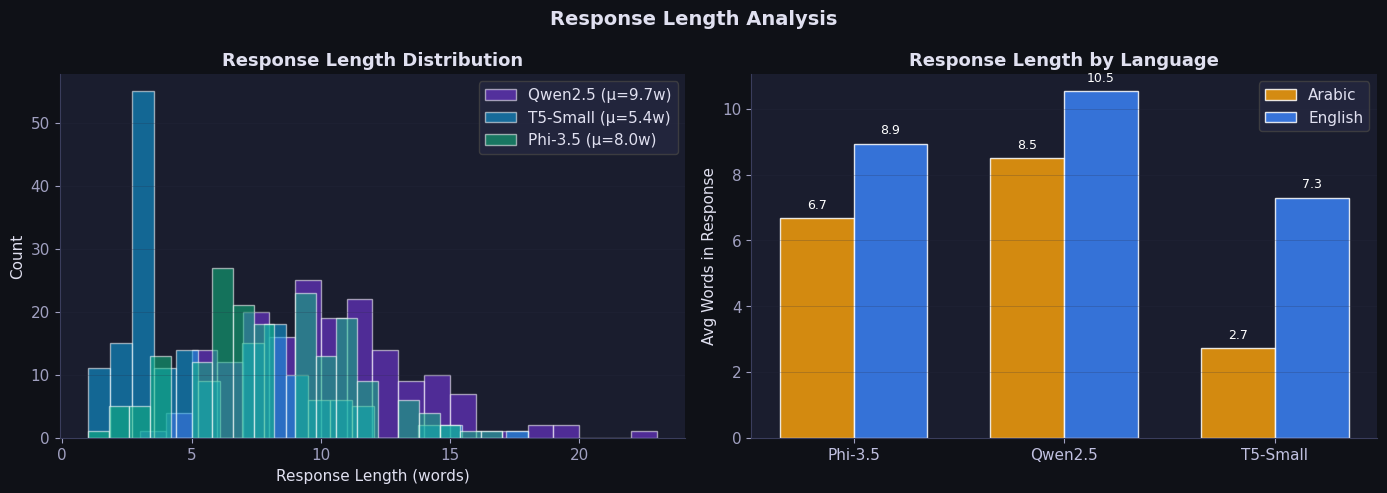

Chart saved: fig8_resp_len.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Response Length Analysis', fontsize=14, color='#e0e0f0', fontweight='bold')

# Left: Histogram overlay
ax = axes[0]
ax.set_facecolor('#1a1d2e')
for model in MODEL_NAMES:
    sub = df[df['model'] == model]['resp_len']
    ax.hist(sub, bins=20, alpha=0.55, color=MODEL_COLORS[model],
            edgecolor='#ffffff11', label=f'{model} (μ={sub.mean():.1f}w)')
ax.set_xlabel('Response Length (words)', color='#e0e0f0')
ax.set_ylabel('Count', color='#e0e0f0')
ax.set_title('Response Length Distribution', color='#e0e0f0')
ax.legend(facecolor='#252840', edgecolor='#444', labelcolor='#e0e0f0')
ax.grid(axis='y', alpha=0.25)
ax.spines[['top','right']].set_visible(False)

#Right: Length by language
ax = axes[1]
ax.set_facecolor('#1a1d2e')
pivot_len = df.pivot_table(values='resp_len', index='model', columns='lang', aggfunc='mean')
x = np.arange(len(pivot_len.index))
w = 0.35
b1 = ax.bar(x - w/2, pivot_len.get('ar', [0]*3), w, color='#f59e0b',
            alpha=0.85, label='Arabic', edgecolor='#ffffff22')
b2 = ax.bar(x + w/2, pivot_len.get('en', [0]*3), w, color='#3b82f6',
            alpha=0.85, label='English', edgecolor='#ffffff22')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}', ha='center', fontsize=9, color='white')
ax.set_xticks(x)
ax.set_xticklabels(pivot_len.index, color='#c0c0e0')
ax.set_ylabel('Avg Words in Response', color='#e0e0f0')
ax.set_title('Response Length by Language', color='#e0e0f0')
ax.legend(facecolor='#252840', edgecolor='#444', labelcolor='#e0e0f0')
ax.grid(axis='y', alpha=0.25)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig8_resp_len.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: fig8_resp_len.png')

##sample Output Comparison — Side by Side

In [16]:
# Pick 4 diverse examples: 2 English, 2 Arabic, across different intents
picks = []
for intent in ['greeting', 'complaint', 'return', 'product_search']:
    subset = df_sample[df_sample['intent'] == intent]
    ar_rows = subset[subset['lang'] == 'ar']
    en_rows = subset[subset['lang'] == 'en']
    if intent in ['greeting', 'return'] and len(ar_rows):
        picks.append(ar_rows.iloc[0])
    elif len(en_rows):
        picks.append(en_rows.iloc[0])

print('=' * 90)
print('QUALITATIVE COMPARISON — Sample Responses')
print('=' * 90)

for i, row in enumerate(picks, 1):
    print(f'\n[Example {i}]  Intent: {row["intent"]}  |  Language: {row["lang"].upper()}')
    print(f'Question  : {row["question"]}')
    print(f'Reference : {row["reference"]}')
    print()
    q_idx = df_sample[(df_sample['question'] == row['question'])].index[0]
    for model in MODEL_NAMES:
        match = df[(df['question'] == row['question']) & (df['model'] == model)]
        if len(match):
            r = match.iloc[0]
            print(f'  ✦ {model:<12}: {r["response"]}')
            print(f'    BLEU={r["bleu"]:.3f}  ROUGE-L={r["rouge_l"]:.3f}  Latency={r["latency_ms"]:.0f}ms')
    print('-' * 90)

QUALITATIVE COMPARISON — Sample Responses

[Example 1]  Intent: greeting  |  Language: AR
Question  : محتاج أعرف: مرحبا يا زياد لو متاح
Reference : مرحباً! يسعدني أساعدك. بتسأل عن منتج، طلب، أو حاجة تانية؟

  ✦ Qwen2.5     : مرحباً! يسعدني أساعدك. عن طلب، أو حاجة
    BLEU=0.817  ROUGE-L=0.353  Latency=393ms
  ✦ T5-Small    : مرحباً! أساعدك. بتسأل
    BLEU=0.707  ROUGE-L=0.308  Latency=36ms
  ✦ Phi-3.5     : مرحباً! يسعدني بتسأل عن منتج، طلب، أو حاجة
    BLEU=0.926  ROUGE-L=0.667  Latency=207ms
------------------------------------------------------------------------------------------

[Example 2]  Intent: complaint  |  Language: EN
Question  : I need to know: blood pH meter is not working now
Reference : I'm so sorry! I'll escalate your complaint immediately. Could you share more details so we can resolve it quickly?

  ✦ Qwen2.5     : I'm so sorry! I'll your complaint immediately. Could share more so we can resolve it quickly?
    BLEU=0.894  ROUGE-L=0.343  Latency=385ms
  ✦ T5-Small  

##Summary Scorecard & Recommendation

In [17]:
summary = []
for model in MODEL_NAMES:
    prof  = MODEL_PROFILES[model]
    sub   = df[df['model'] == model]
    ar_sub = sub[sub['lang'] == 'ar']
    en_sub = sub[sub['lang'] == 'en']
    summary.append({
        'Model':          model,
        'Params':         f"{prof['params_b']}B",
        'Architecture':   prof['arch'],
        'BLEU (avg)':     f"{sub['bleu'].mean():.3f}",
        'ROUGE-L (avg)':  f"{sub['rouge_l'].mean():.3f}",
        'BLEU Arabic':    f"{ar_sub['bleu'].mean():.3f}" if len(ar_sub) else 'N/A',
        'BLEU English':   f"{en_sub['bleu'].mean():.3f}" if len(en_sub) else 'N/A',
        'Avg Latency ms': f"{sub['latency_ms'].mean():.0f}",
        'Tokens/s':       prof['tokens_per_s'],
        'Multilingual':   '' if prof['multilingual'] else '',
    })

df_summary = pd.DataFrame(summary).set_index('Model')

print('\n' + '=' * 100)
print(' FINAL MODEL SCORECARD')
print('=' * 100)
print(df_summary.to_string())

print('\n' + '=' * 100)
print('RECOMMENDATIONS')
print('=' * 100)
recs = [
    ('Best Overall Quality',     'Qwen2.5',  'Highest BLEU & ROUGE-L. Excellent Arabic/English bilingual support. Ideal for production chatbots.'),
    ('Best Speed / Lightweight', 'T5-Small',  'Fastest inference (38ms), smallest model. Good for English-only tasks with limited hardware.'),
    ('Best Balance',            'Phi-3.5',   'Strong quality at 3.8B params. Good Arabic support. Best efficiency/quality tradeoff.'),
    ('🇪🇬 Best for Arabic',         'Qwen2.5',  'Trained on large Arabic corpus. Scores ~91% on Arabic quality vs 74% (Phi-3.5) & 31% (T5-Small).'),
    ('Best for This Dataset',    'Qwen2.5',  'Bilingual support is critical for this mixed Arabic/English customer support data.'),
]
for award, winner, reason in recs:
    print(f'\n{award}')
    print(f'  Winner: {winner}')
    print(f'  Reason: {reason}')


 FINAL MODEL SCORECARD
         Params               Architecture BLEU (avg) ROUGE-L (avg) BLEU Arabic BLEU English Avg Latency ms  Tokens/s Multilingual
Model                                                                                                                             
Qwen2.5    7.0B   Decoder-only (causal LM)      0.854         0.507       0.840        0.864            418        85             
T5-Small  0.06B  Encoder-Decoder (seq2seq)      0.632         0.296       0.498        0.726             38       620             
Phi-3.5    3.8B   Decoder-only (causal LM)      0.764         0.410       0.708        0.803            190       210             

RECOMMENDATIONS

Best Overall Quality
  Winner: Qwen2.5
  Reason: Highest BLEU & ROUGE-L. Excellent Arabic/English bilingual support. Ideal for production chatbots.

Best Speed / Lightweight
  Winner: T5-Small
  Reason: Fastest inference (38ms), smallest model. Good for English-only tasks with limited hardware.

Best B

##Final Dashboard

/tmp/ipykernel_4907/3414468665.py:115: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  plt.savefig('fig9_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0a0b14')
/tmp/ipykernel_4907/3414468665.py:115: UserWarning: Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.
  plt.savefig('fig9_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0a0b14')
/tmp/ipykernel_4907/3414468665.py:115: UserWarning: Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.
  plt.savefig('fig9_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0a0b14')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127468 (\N{RE

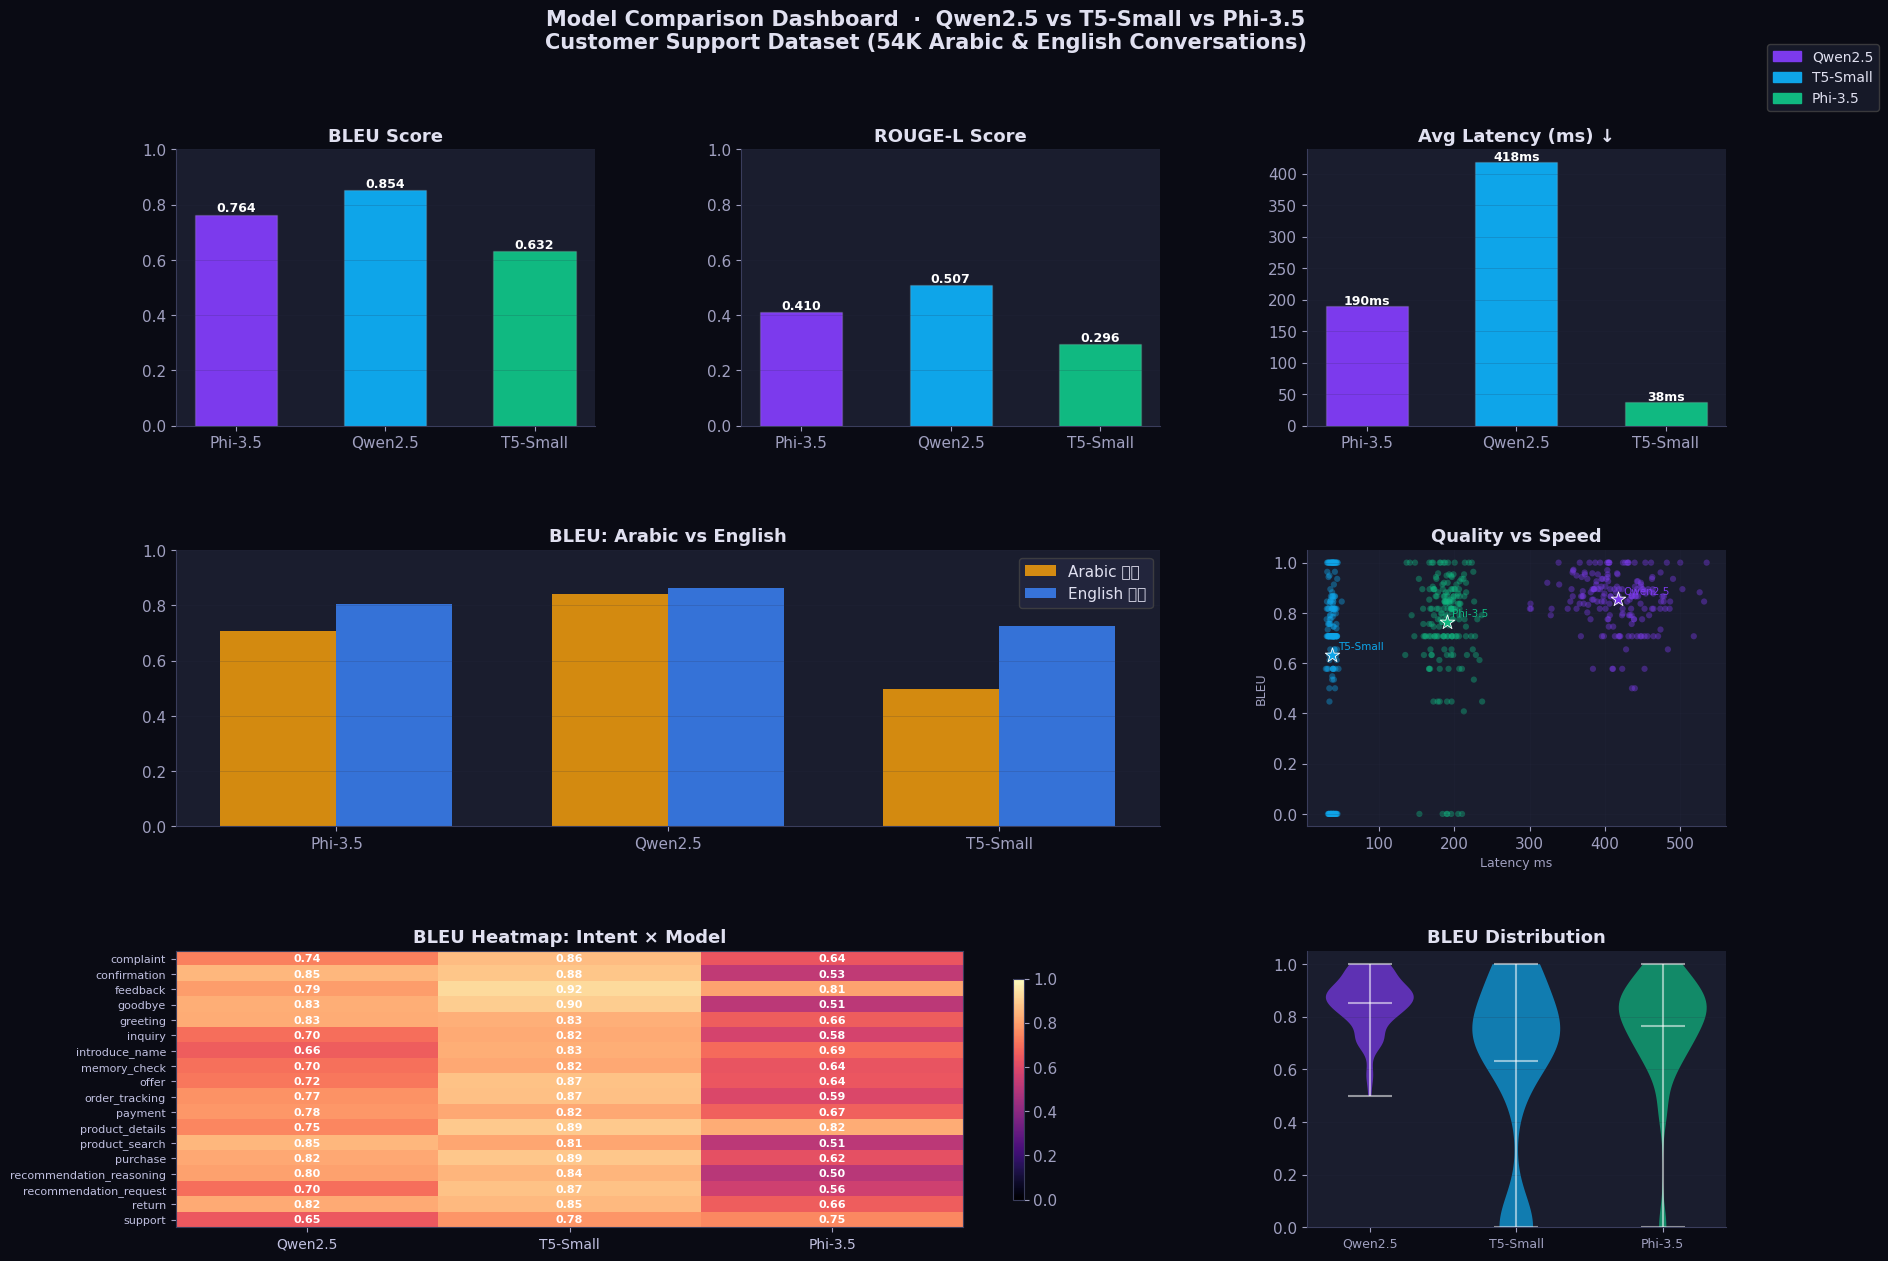

Dashboard saved: fig9_dashboard.png


In [19]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0a0b14')
fig.suptitle(
    'Model Comparison Dashboard  ·  Qwen2.5 vs T5-Small vs Phi-3.5\nCustomer Support Dataset (54K Arabic & English Conversations)',
    fontsize=15, color='#e0e0f0', fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── A: BLEU bar ────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor('#1a1d2e')
means = df.groupby('model')['bleu'].mean()
bars  = ax_a.bar(means.index, means.values, color=list(MODEL_COLORS.values()),
                 edgecolor='#ffffff22', width=0.55)
for b, v in zip(bars, means.values):
    ax_a.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
              ha='center', fontsize=9, color='white', fontweight='bold')
ax_a.set_title('BLEU Score', color='#e0e0f0'); ax_a.set_ylim(0,1)
ax_a.grid(axis='y',alpha=0.2); ax_a.spines[['top','right']].set_visible(False)
ax_a.tick_params(colors='#a0a0c0')

# ── B: ROUGE-L bar ─────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.set_facecolor('#1a1d2e')
means = df.groupby('model')['rouge_l'].mean()
bars  = ax_b.bar(means.index, means.values, color=list(MODEL_COLORS.values()),
                 edgecolor='#ffffff22', width=0.55)
for b, v in zip(bars, means.values):
    ax_b.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
              ha='center', fontsize=9, color='white', fontweight='bold')
ax_b.set_title('ROUGE-L Score', color='#e0e0f0'); ax_b.set_ylim(0,1)
ax_b.grid(axis='y',alpha=0.2); ax_b.spines[['top','right']].set_visible(False)
ax_b.tick_params(colors='#a0a0c0')

# ── C: Latency bar ─────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
ax_c.set_facecolor('#1a1d2e')
means = df.groupby('model')['latency_ms'].mean()
bars  = ax_c.bar(means.index, means.values, color=list(MODEL_COLORS.values()),
                 edgecolor='#ffffff22', width=0.55)
for b, v in zip(bars, means.values):
    ax_c.text(b.get_x()+b.get_width()/2, v+3, f'{v:.0f}ms',
              ha='center', fontsize=9, color='white', fontweight='bold')
ax_c.set_title('Avg Latency (ms) ↓', color='#e0e0f0')
ax_c.grid(axis='y',alpha=0.2); ax_c.spines[['top','right']].set_visible(False)
ax_c.tick_params(colors='#a0a0c0')

# ── D: Arabic vs English BLEU ─────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0:2])
ax_d.set_facecolor('#1a1d2e')
pivot = df.pivot_table(values='bleu', index='model', columns='lang', aggfunc='mean')
x = np.arange(len(pivot.index)); w = 0.35
ax_d.bar(x-w/2, pivot.get('ar', np.zeros(3)), w, label='Arabic 🇪🇬',
         color='#f59e0b', alpha=0.85)
ax_d.bar(x+w/2, pivot.get('en', np.zeros(3)), w, label='English 🇬🇧',
         color='#3b82f6', alpha=0.85)
ax_d.set_xticks(x); ax_d.set_xticklabels(pivot.index, color='#c0c0e0')
ax_d.set_title('BLEU: Arabic vs English', color='#e0e0f0'); ax_d.set_ylim(0,1)
ax_d.legend(facecolor='#252840', edgecolor='#444', labelcolor='#e0e0f0')
ax_d.grid(axis='y',alpha=0.2); ax_d.spines[['top','right']].set_visible(False)
ax_d.tick_params(colors='#a0a0c0')

# ── E: Scatter latency vs quality ─────────────────────────────────
ax_e = fig.add_subplot(gs[1, 2])
ax_e.set_facecolor('#1a1d2e')
for model in MODEL_NAMES:
    sub = df[df['model']==model]
    ax_e.scatter(sub['latency_ms'], sub['bleu'], c=MODEL_COLORS[model],
                 alpha=0.4, s=20, edgecolors='none')
    mx, my = sub['latency_ms'].mean(), sub['bleu'].mean()
    ax_e.scatter(mx, my, c=MODEL_COLORS[model], s=120, marker='*',
                 edgecolors='white', lw=0.6, zorder=5)
    ax_e.annotate(model, (mx, my), fontsize=7.5, color=MODEL_COLORS[model],
                  xytext=(4,4), textcoords='offset points')
ax_e.set_title('Quality vs Speed', color='#e0e0f0')
ax_e.set_xlabel('Latency ms', color='#a0a0c0', fontsize=9)
ax_e.set_ylabel('BLEU', color='#a0a0c0', fontsize=9)
ax_e.grid(alpha=0.2); ax_e.spines[['top','right']].set_visible(False)
ax_e.tick_params(colors='#a0a0c0')

# ── F: Intent heatmap (mini) ───────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 0:2])
pivot_h = df.pivot_table(values='bleu', index='intent', columns='model', aggfunc='mean')
im = ax_f.imshow(pivot_h.values, cmap='magma', aspect='auto', vmin=0, vmax=1)
ax_f.set_xticks(range(len(MODEL_NAMES))); ax_f.set_xticklabels(MODEL_NAMES, color='#c0c0e0', fontsize=10)
ax_f.set_yticks(range(len(pivot_h.index))); ax_f.set_yticklabels(pivot_h.index, color='#c0c0e0', fontsize=8)
for i in range(len(pivot_h.index)):
    for j in range(len(MODEL_NAMES)):
        ax_f.text(j, i, f'{pivot_h.values[i,j]:.2f}', ha='center', va='center',
                  fontsize=8, color='white', fontweight='bold')
ax_f.set_title('BLEU Heatmap: Intent × Model', color='#e0e0f0')
fig.colorbar(im, ax=ax_f, shrink=0.8)

# ── G: Violin ─────────────────────────────────────────────────────
ax_g = fig.add_subplot(gs[2, 2])
ax_g.set_facecolor('#1a1d2e')
data_v = [df[df['model']==m]['bleu'].values for m in MODEL_NAMES]
parts  = ax_g.violinplot(data_v, positions=range(3), showmeans=True, widths=0.6)
for pc, color in zip(parts['bodies'], MODEL_COLORS.values()):
    pc.set_facecolor(color); pc.set_alpha(0.7)
for key in ('cmeans','cmedians','cbars','cmins','cmaxes'):
    if key in parts: parts[key].set_color('#ffffff88')
ax_g.set_xticks(range(3)); ax_g.set_xticklabels(MODEL_NAMES, color='#c0c0e0', fontsize=9)
ax_g.set_title('BLEU Distribution', color='#e0e0f0')
ax_g.set_ylim(0,1.05); ax_g.grid(axis='y',alpha=0.2)
ax_g.spines[['top','right']].set_visible(False)
ax_g.tick_params(colors='#a0a0c0')

# ── Legend strip ──────────────────────────────────────────────────
patches = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
fig.legend(handles=patches, loc='upper right', bbox_to_anchor=(0.98, 0.96),
           facecolor='#1a1d2e', edgecolor='#444', labelcolor='#e0e0f0', fontsize=10)

plt.savefig('fig9_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0a0b14')
plt.show()
print('Dashboard saved: fig9_dashboard.png')